In [10]:
import pandas as pd
import numpy as np

my_folder = "Versionen/testversion"

df = pd.read_parquet(my_folder + "/History.parquet")
cards = pd.read_pickle(my_folder + "/cards.pkl")

final_games = (
    df
    .loc[df["runde"] == 4]
    .drop_duplicates(subset="game_id")
    .copy()
)

n_games = len(final_games)
total_sp = final_games["sp"].sum()

print(f"Games analysed: {n_games:,}")

Games analysed: 10,000


# Analyze cards played
One row per play

In [11]:
plays_df = (
    final_games[
        ["game_id", "sp", "played_cards_log"]
    ]
    .explode("played_cards_log", ignore_index=True)
    .dropna(subset=["played_cards_log"])
)

plays_df["card_id"] = plays_df["played_cards_log"].apply(
    lambda entry: entry["card_id"]
)

plays_df["played_round"] = plays_df["played_cards_log"].apply(
    lambda entry: entry["runde"]
)

plays_df = (
    plays_df
    .drop(columns="played_cards_log")
    .merge(
        cards[
            ["id", "Name", "Slot/Stapel", "Kosten"]
        ].drop_duplicates("id"),
        left_on="card_id",
        right_on="id",
        how="left",
        validate="many_to_one",
    )
    .drop(columns="id")
)
#3. Ensure each card counts only once per game
game_cards = (
    plays_df[
        [
            "game_id",
            "card_id",
            "Name",
            "Slot/Stapel",
            "Kosten",
            "sp",
            "played_round",
        ]
    ]
    .drop_duplicates(["game_id", "card_id"])
)

print(f"Card Plays analysed: {len(game_cards):,}")

Card Plays analysed: 128,341


# Compare final SP with and without each card

In [12]:

card_results = (
    game_cards
    .groupby(
        ["card_id", "Name", "Slot/Stapel", "Kosten"],
        dropna=False,
    )
    .agg(
        games_with_card=("game_id", "nunique"),
        sp_sum_with_card=("sp", "sum"),
        mean_sp_with_card=("sp", "mean"),
        mean_played_round=("played_round", "mean"),
    )
    .reset_index()
)

card_results["games_without_card"] = (
    n_games - card_results["games_with_card"]
)

card_results["mean_sp_without_card"] = np.where(
    card_results["games_without_card"] > 0,
    (
        total_sp - card_results["sp_sum_with_card"]
    ) / card_results["games_without_card"],
    np.nan,
)

card_results["sp_uplift"] = (
    card_results["mean_sp_with_card"]
    - card_results["mean_sp_without_card"]
)

card_results["play_rate"] = (
    card_results["games_with_card"] / n_games
)

In [13]:
minimum_games = 100

reliable_cards = (
    card_results
    .loc[card_results["games_with_card"] >= minimum_games]
    .sort_values("sp_uplift", ascending=False)
)

reliable_cards[
    [
        "Name",
        "Slot/Stapel",
        "Kosten",
        "games_with_card",
        "play_rate",
        "mean_played_round",
        "mean_sp_with_card",
        "mean_sp_without_card",
        "sp_uplift",
    ]
].head(30)

,Name,Slot/Stapel,Kosten,games_with_card,play_rate,mean_played_round,mean_sp_with_card,mean_sp_without_card,sp_uplift
38,Passivhaussanierung ökologisch,Dämmung,5,439,0.0439,2.605923,24.202733,19.019349,5.183384
25,Grosse Dach-PV-Anlage,Dachnutzung,3,850,0.0850,2.050588,23.195294,18.880109,4.315185
2,Ambitionierte Sanierung ökologisch,Dämmung,4,825,0.0825,2.111515,23.132121,18.897548,4.234574
14,Effiziente Haushaltsgeräte,*Flexibilität,0,2973,0.2973,2.943155,21.966028,18.096485,3.869543
23,Flexibles Lastmanagement,*Flexibilität,0,6835,0.6835,2.330505,20.320556,16.928278,3.392278
22,Fernwärme-Anschluss,Wärmeerzeugung,2,1147,0.1147,2.117698,22.222319,18.861403,3.360916
35,Mittlere Dach-PV-Anlage,Dachnutzung,2,1043,0.1043,2.031640,22.249281,18.897287,3.351994
48,Wärmerückgewinnung des Duschwassers,*Effizienz,1,2712,0.2712,3.203909,21.616150,18.365258,3.250892
45,Thermische Flexibilität,*Flexibilität,0,2874,0.2874,2.999652,21.516006,18.331743,3.184263
31,LED Beleuchtung,*Effizienz,1,6318,0.6318,2.637227,20.373061,17.314503,3.058558


<Axes: xlabel='sp_uplift', ylabel='play_rate'>

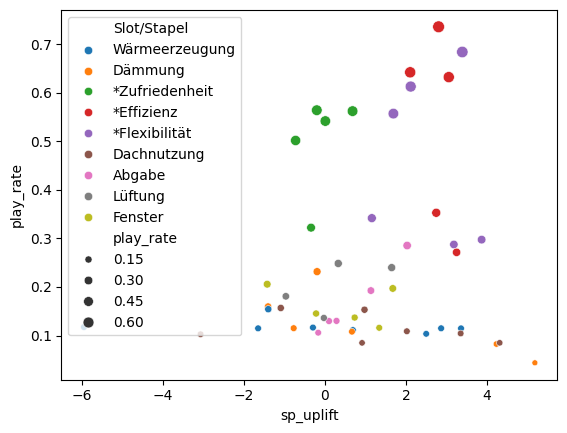

In [22]:
import seaborn as sns
from card_colors import slot_colors
sns.scatterplot(card_results, x="sp_uplift", y="play_rate", hue="Slot/Stapel", size="play_rate")

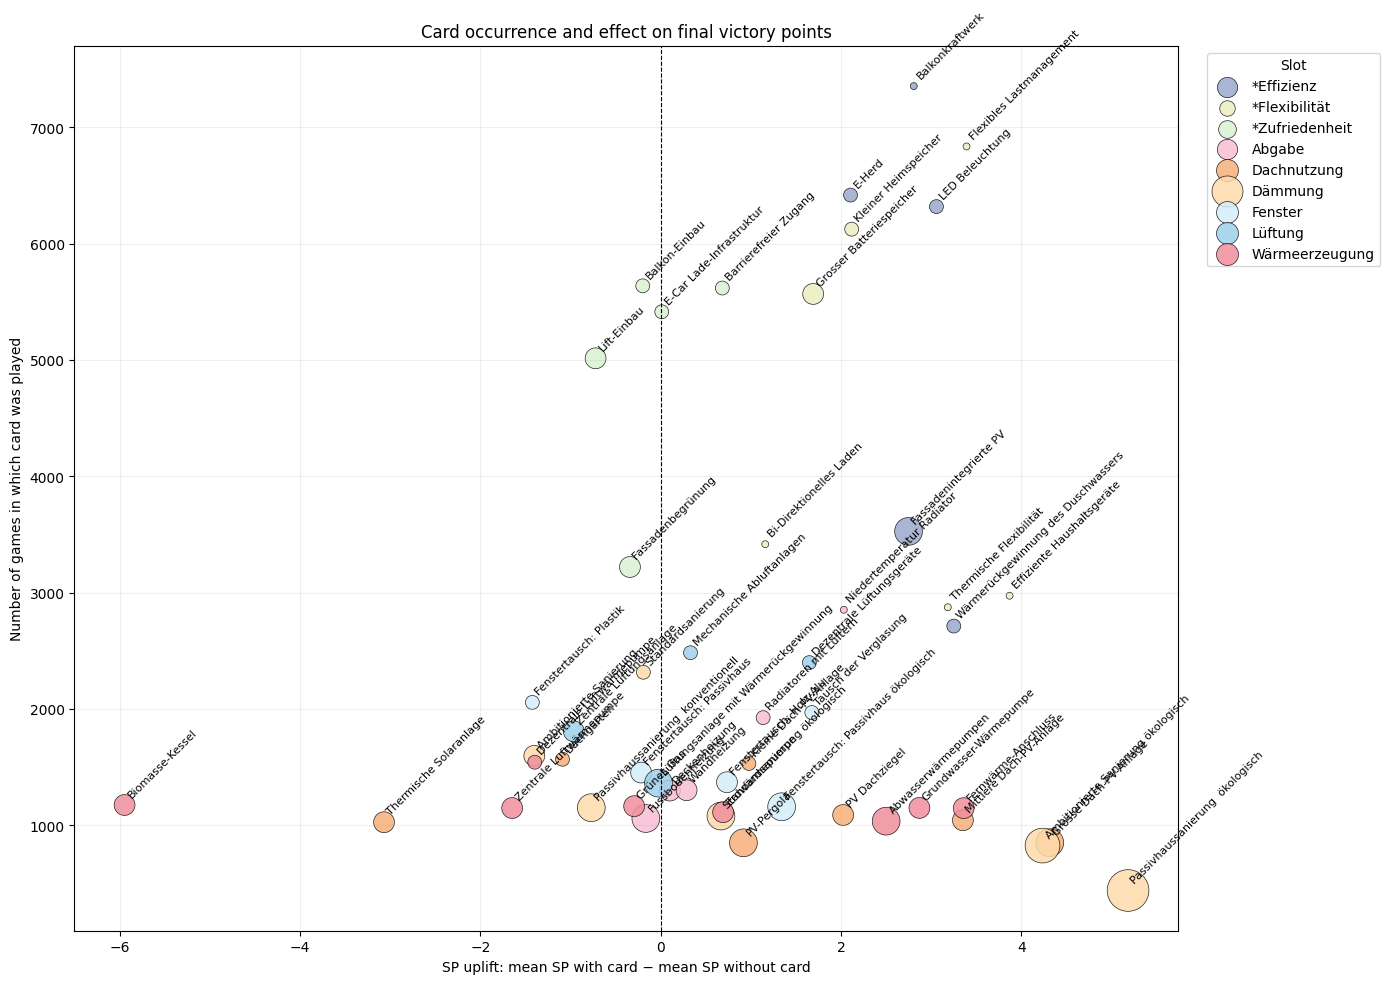

In [27]:
import matplotlib.pyplot as plt

from card_colors import *

plot_data = (
    card_results
    .dropna(
        subset=[
            "sp_uplift",
            "Kosten",
            "Name",
            "Slot/Stapel",
            "games_with_card",
        ]
    )
    .copy()
)

# Marker radius proportional to card cost.
# Matplotlib's s parameter represents marker area, so the radius is squared.
size_scale = 5
plot_data["marker_size"] = (
    plot_data["Kosten"].clip(lower=0) * size_scale + 5
) ** 2

fig, ax = plt.subplots(figsize=(14, 10))

# Separate scatter call per slot creates the legend
for slot, group in plot_data.groupby("Slot/Stapel"):
    ax.scatter(
        group["sp_uplift"],
        group["games_with_card"],
        color=slot_colors.get(slot, default_color),
        edgecolor="black",
        linewidth=0.5,
        s=group["marker_size"],
        alpha=0.85,
        label=slot,
    )

# Card-name annotations
for _, row in plot_data.iterrows():
    ax.annotate(
        row["Name"],
        xy=(row["sp_uplift"], row["games_with_card"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        rotation=45,
        rotation_mode="anchor",
    )

ax.axvline(
    0,
    color="black",
    linewidth=0.8,
    linestyle="--",
)

ax.set_title("Card occurrence and effect on final victory points")
ax.set_xlabel("SP uplift: mean SP with card − mean SP without card")
ax.set_ylabel("Number of games in which card was played")

ax.legend(
    title="Slot",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

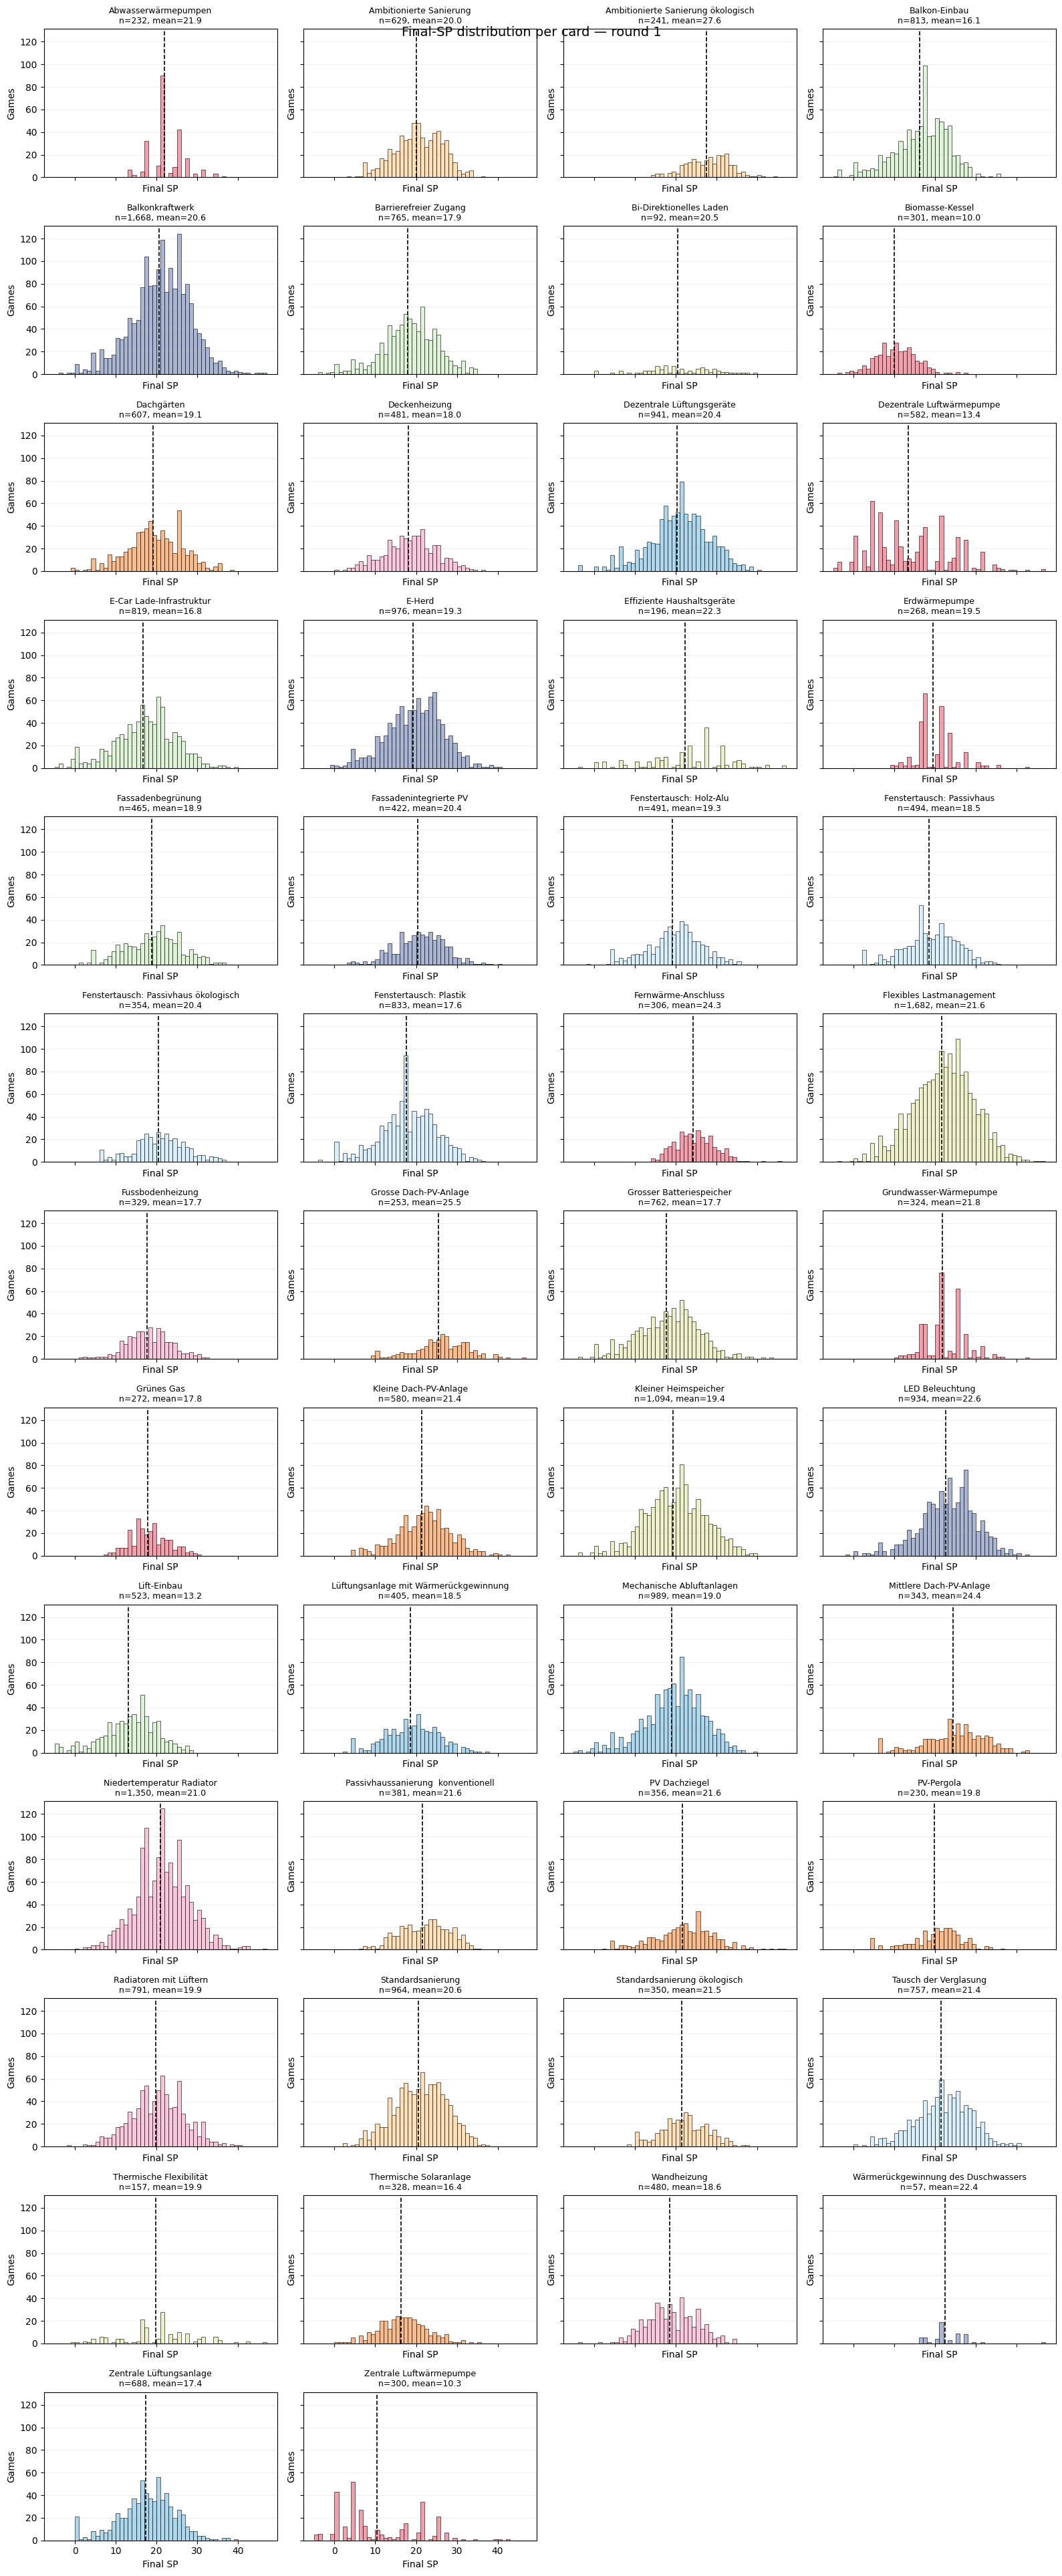

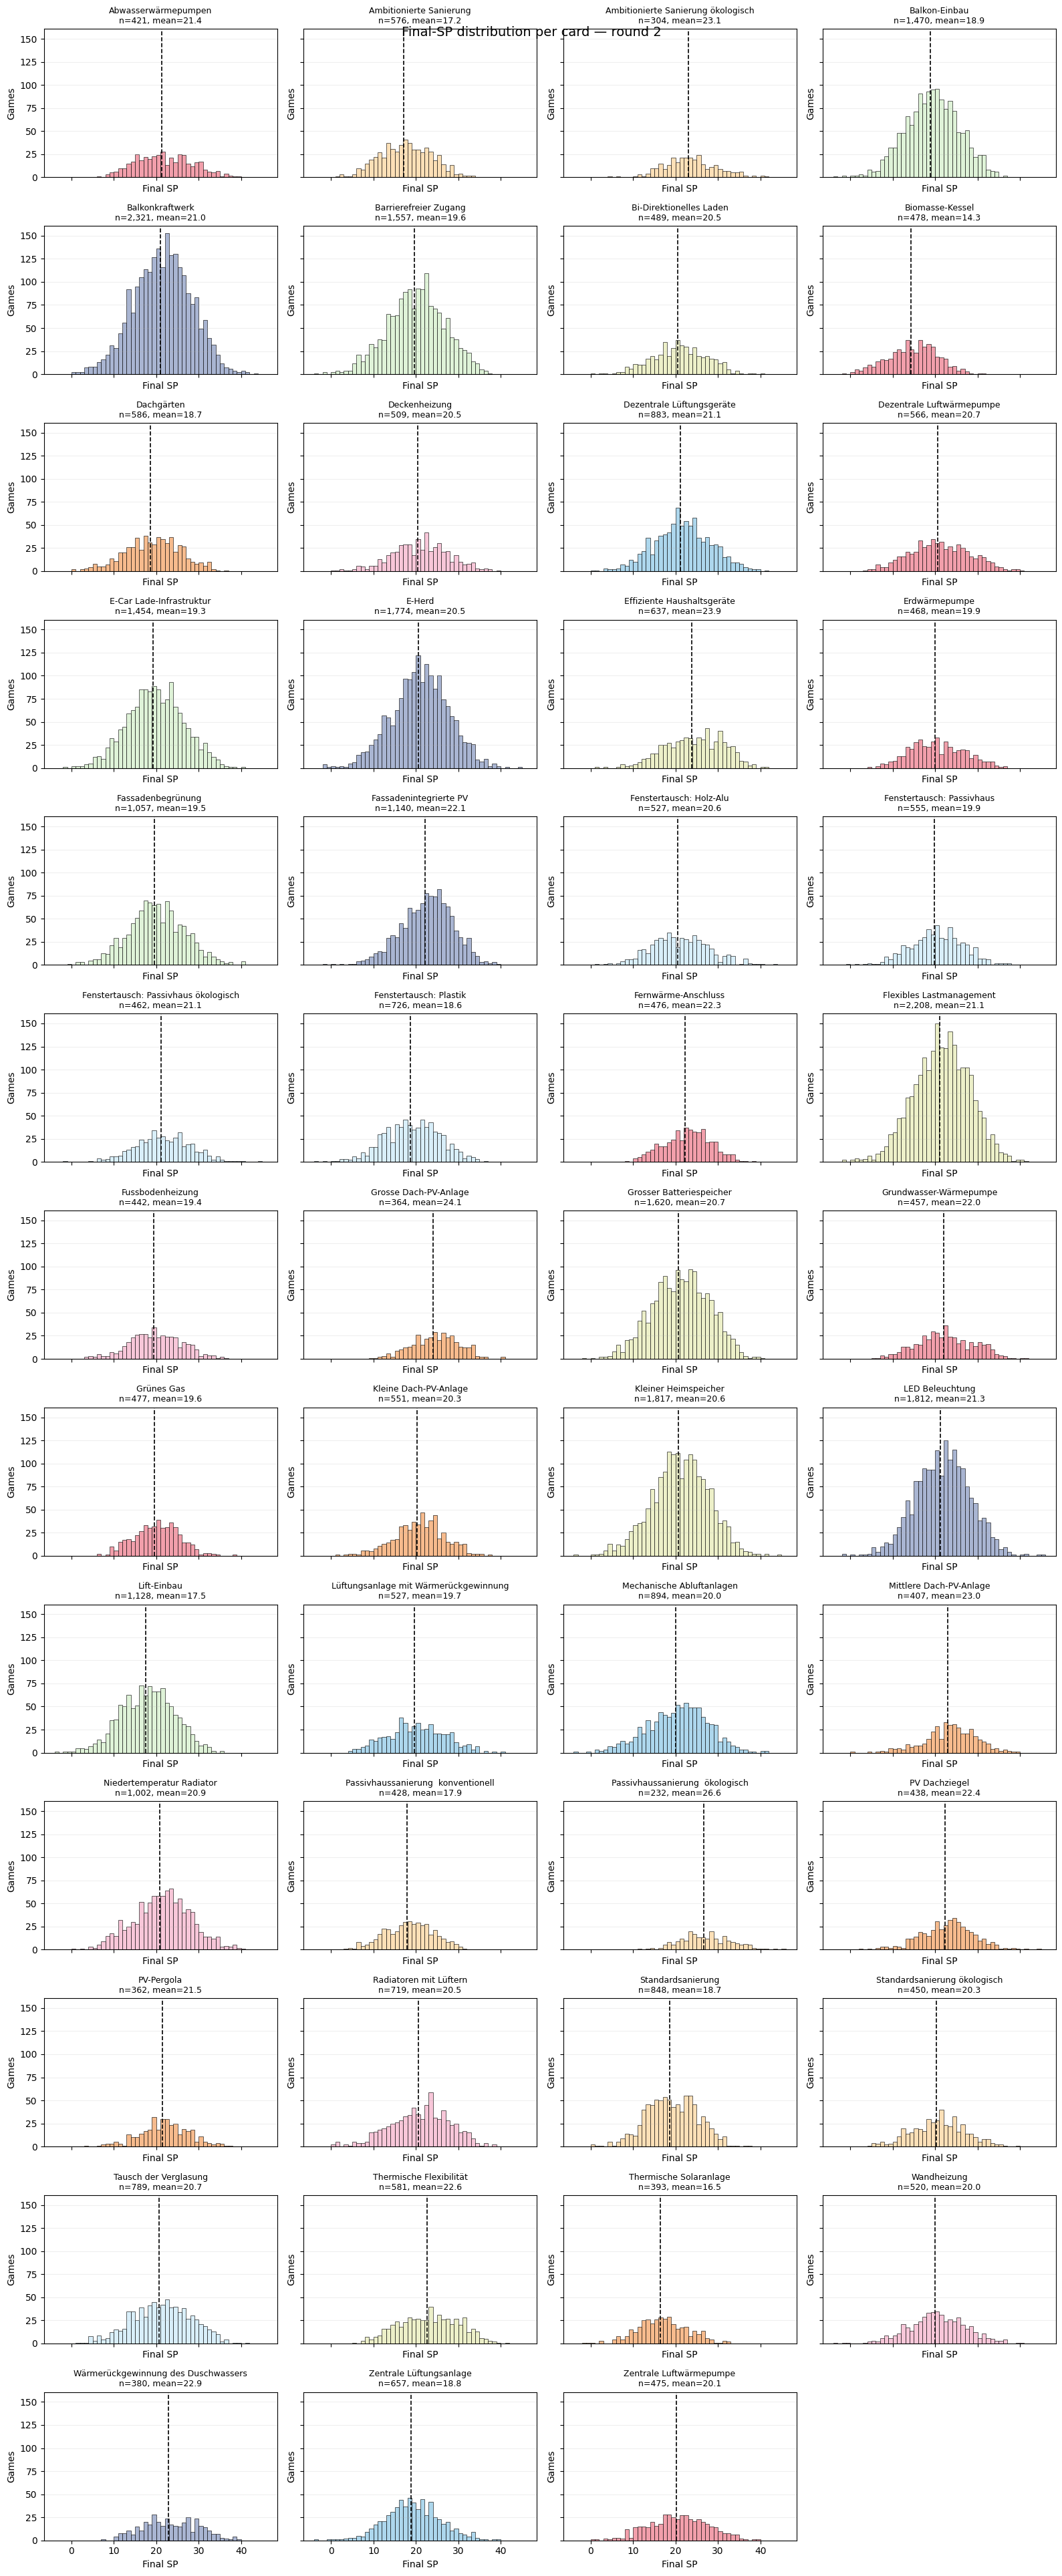

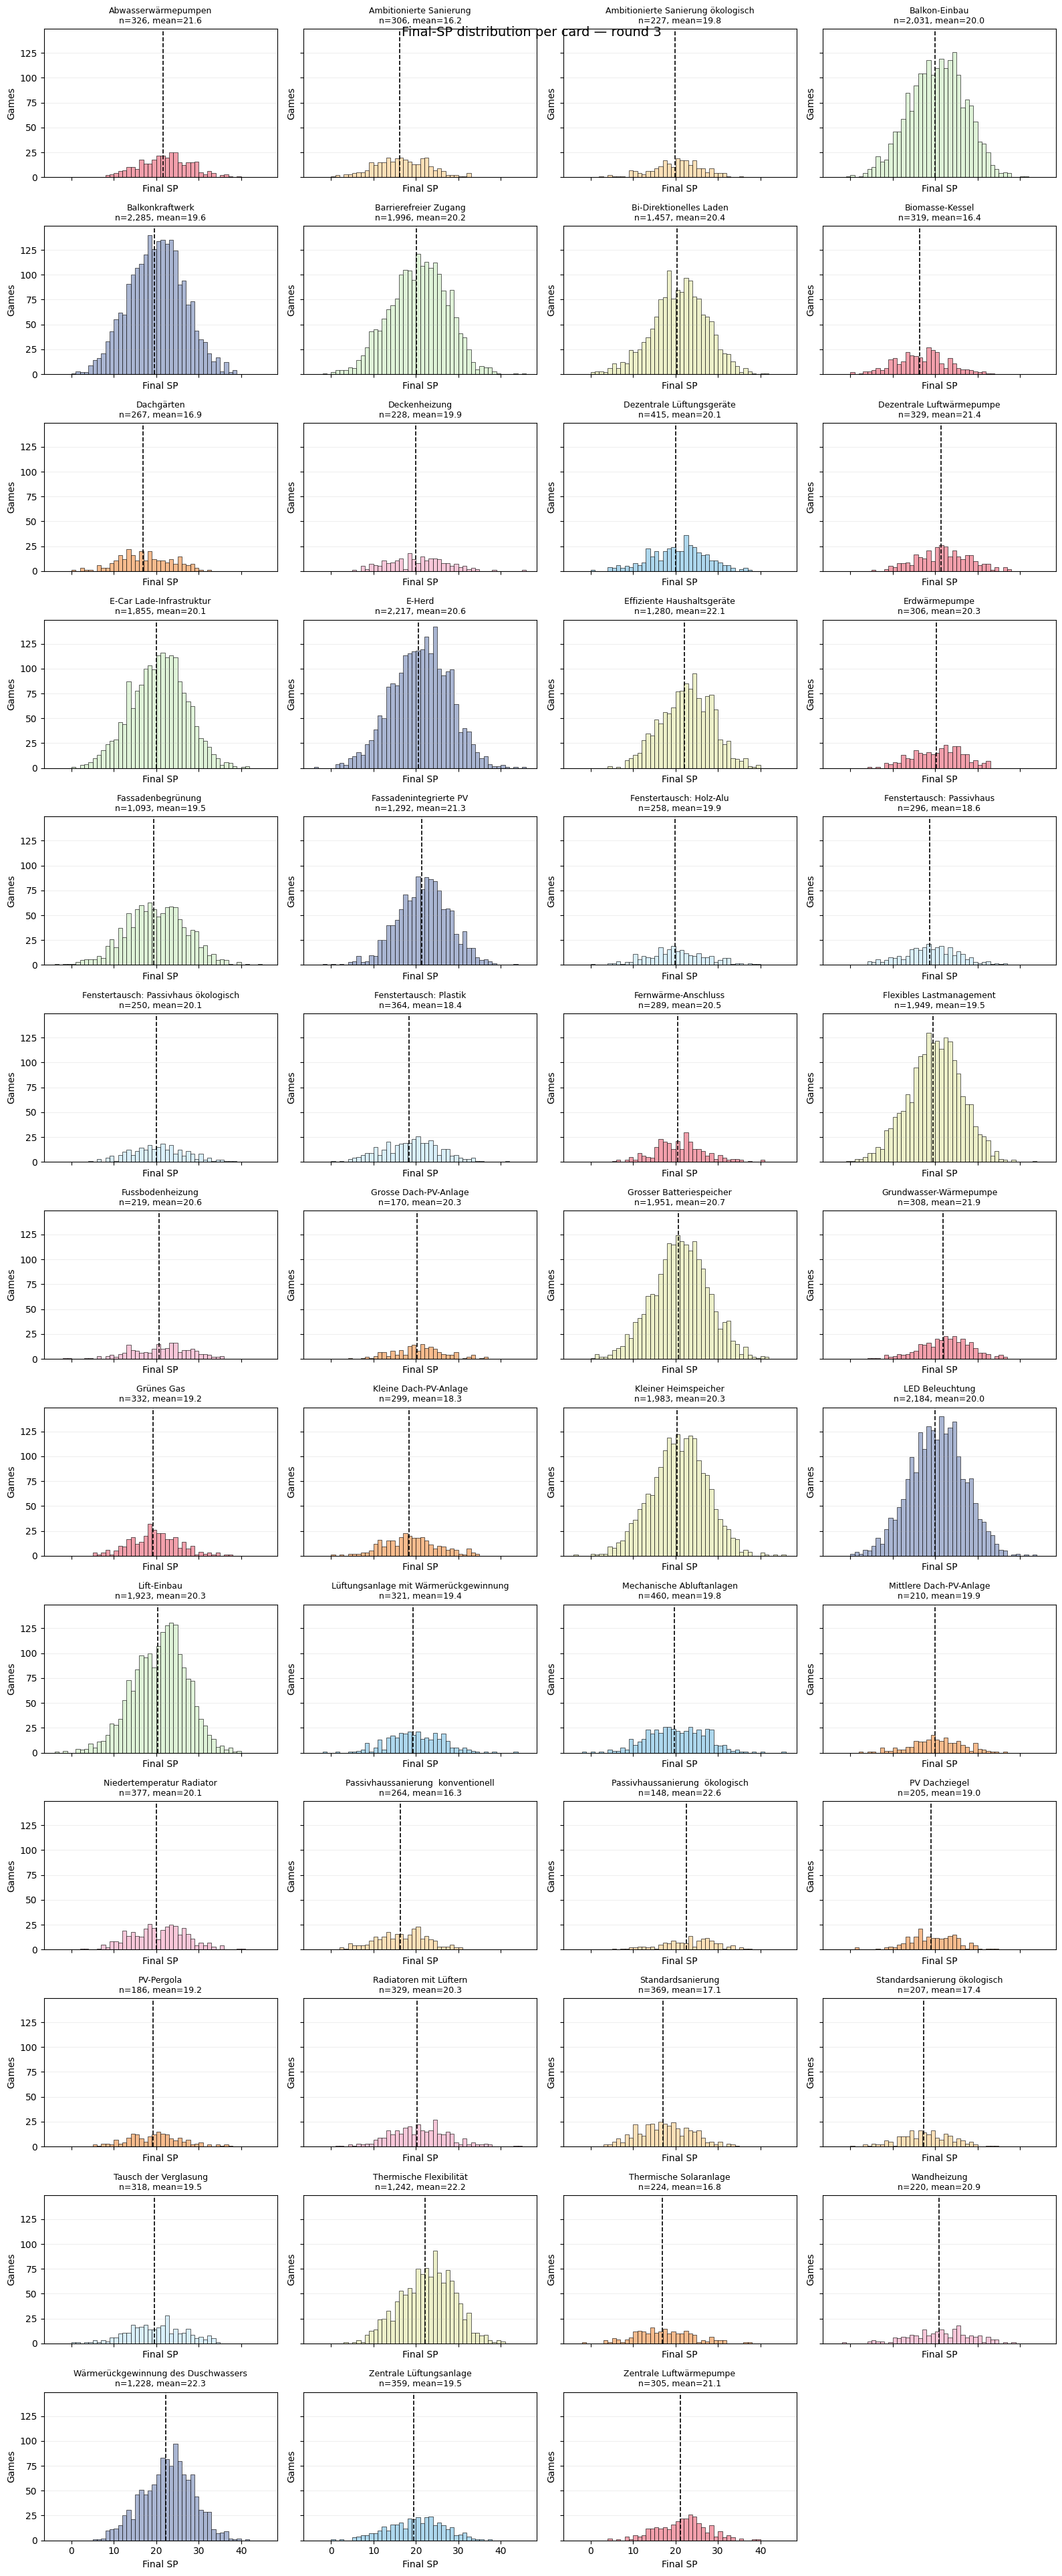

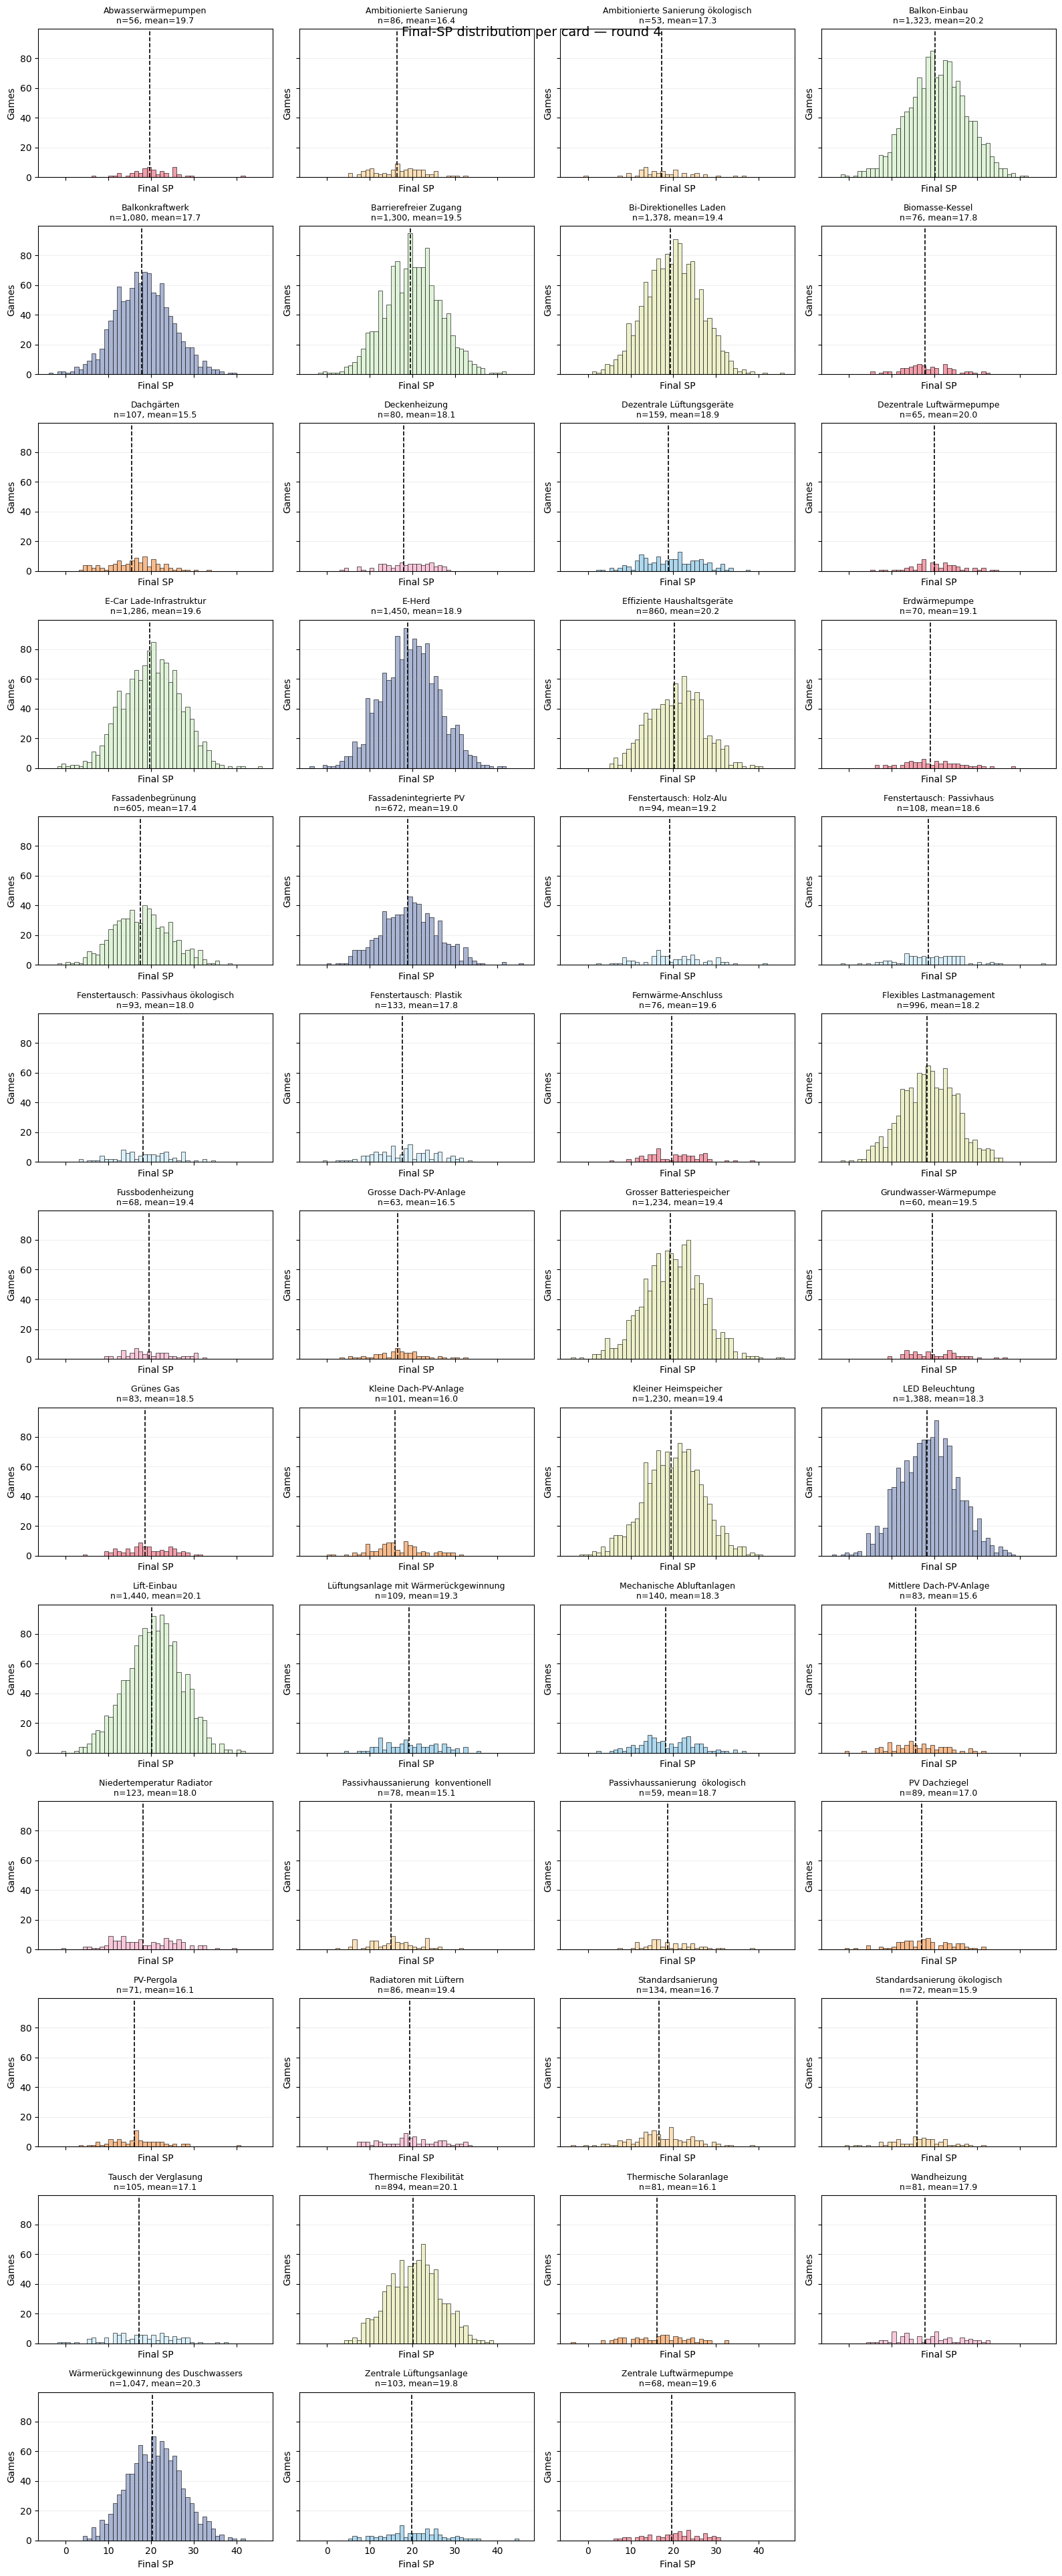

In [24]:
import math
import matplotlib.pyplot as plt

from card_colors import slot_colors, default_color

for round_number in [1, 2, 3, 4]:

    round_data = plays_df.loc[
        plays_df["played_round"] == round_number
    ].copy()

    card_groups = list(
        round_data.groupby(
            ["card_id", "Name", "Slot/Stapel"],
            sort=True,
        )
    )

    n_cards = len(card_groups)
    n_cols = 4
    n_rows = math.ceil(n_cards / n_cols)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    axes = axes.flatten()

    # Same bins for every card in this round
    bins = range(
        int(round_data["sp"].min()),
        int(round_data["sp"].max()) + 2,
    )

    for ax, ((card_id, name, slot), group) in zip(
        axes,
        card_groups,
    ):
        ax.hist(
            group["sp"],
            bins=bins,
            color=slot_colors.get(slot, default_color),
            edgecolor="black",
            linewidth=0.5,
            alpha=0.85,
        )

        ax.axvline(
            group["sp"].mean(),
            color="black",
            linewidth=1.2,
            linestyle="--",
        )

        ax.set_title(
            f"{name}\n"
            f"n={len(group):,}, mean={group['sp'].mean():.1f}",
            fontsize=9,
        )

        ax.set_xlabel("Final SP")
        ax.set_ylabel("Games")
        ax.grid(axis="y", alpha=0.2)

    # Hide unused axes
    for ax in axes[n_cards:]:
        ax.axis("off")

    fig.suptitle(
        f"Final-SP distribution per card — round {round_number}",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

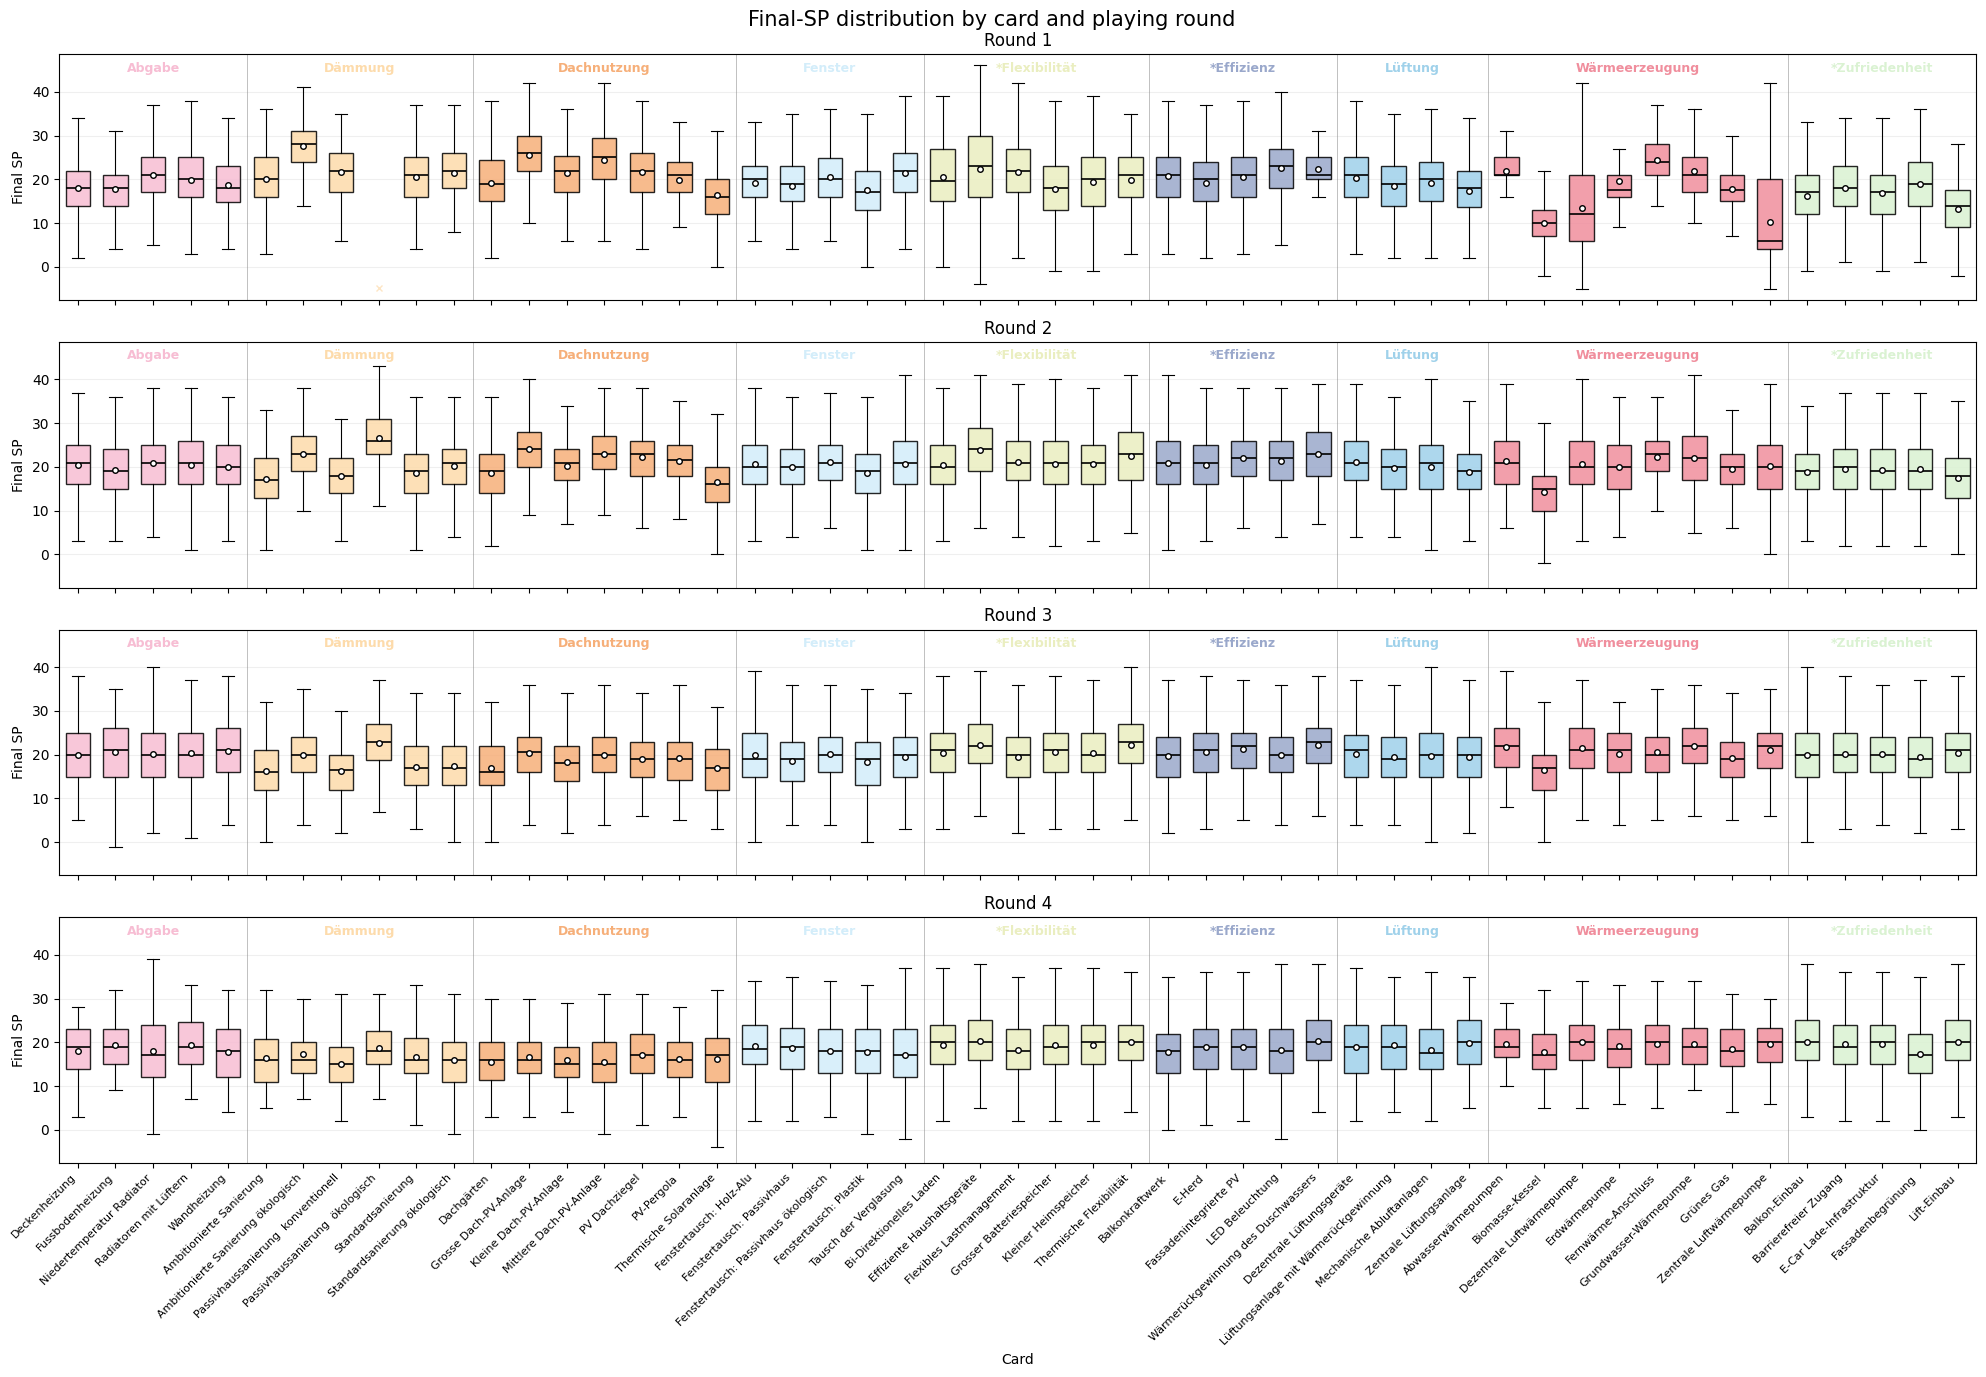

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from card_colors import slot_colors, default_color

slot_order = [
    "Abgabe",
    "Dämmung",
    "Dachnutzung",
    "Fenster",
    "*Flexibilität",
    "*Effizienz",
    "Lüftung",
    "Wärmeerzeugung",
    "*Zufriedenheit",
]

# Unique cards in stable order
card_index = (
    plays_df[["card_id", "Name", "Slot/Stapel"]]
    .drop_duplicates()
    .copy()
)

card_index["slot_sort"] = pd.Categorical(
    card_index["Slot/Stapel"],
    categories=slot_order,
    ordered=True,
)

card_index = (
    card_index
    .sort_values(["slot_sort", "Name"])
    .reset_index(drop=True)
)

positions = np.arange(len(card_index))

# Slot group boundaries for separators and labels
slot_groups = (
    card_index
    .reset_index()
    .groupby("Slot/Stapel", sort=False, observed=True)
    .agg(
        start=("index", "min"),
        end=("index", "max"),
    )
    .reset_index()
)

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(20, 14),
    sharex=True,
    sharey=True,
)

for ax, round_number in zip(axes, [1, 2, 3, 4]):

    distributions = []
    valid_positions = []
    valid_slots = []
    missing_cards = []

    # Collect per-card distributions for this round
    for position, card in card_index.iterrows():
        values = (
            plays_df.loc[
                plays_df["card_id"].eq(card["card_id"])
                & plays_df["played_round"].eq(round_number),
                "sp",
            ]
            .dropna()
            .to_numpy()
        )

        if len(values) > 0:
            distributions.append(values)
            valid_positions.append(position)
            valid_slots.append(card["Slot/Stapel"])
        else:
            missing_cards.append((position, card["Slot/Stapel"]))

    # Draw boxplots only for cards that have data
    if distributions:
        boxplot = ax.boxplot(
            distributions,
            positions=valid_positions,
            widths=0.65,
            patch_artist=True,
            showfliers=False,
            showmeans=True,
            medianprops={
                "color": "black",
                "linewidth": 1.2,
            },
            meanprops={
                "marker": "o",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 4,
            },
            whiskerprops={
                "color": "black",
                "linewidth": 0.8,
            },
            capprops={
                "color": "black",
                "linewidth": 0.8,
            },
        )

        # Color boxes by slot
        for box, slot in zip(boxplot["boxes"], valid_slots):
            box.set_facecolor(slot_colors.get(slot, default_color))
            box.set_edgecolor("black")
            box.set_alpha(0.85)

    # Mark cards with no data in this round
    ymin, ymax = ax.get_ylim()
    marker_y = ymin + 0.05 * (ymax - ymin) if ymax > ymin else 0

    for position, slot in missing_cards:
        ax.plot(
            position,
            marker_y,
            marker="x",
            color=slot_colors.get(slot, default_color),
            markersize=5,
            alpha=0.7,
        )

    ax.set_title(f"Round {round_number}")
    ax.set_ylabel("Final SP")
    ax.grid(axis="y", alpha=0.2)

    # Slot separators and labels
    for _, group in slot_groups.iterrows():
        start = group["start"]
        end = group["end"]
        slot = group["Slot/Stapel"]

        ax.axvline(
            end + 0.5,
            color="grey",
            linewidth=0.7,
            alpha=0.5,
        )

        midpoint = (start + end) / 2
        ax.text(
            midpoint,
            0.97,
            slot,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=9,
            fontweight="bold",
            color=slot_colors.get(slot, default_color),
        )

# X labels only at bottom
axes[-1].set_xticks(positions)
axes[-1].set_xticklabels(
    card_index["Name"],
    rotation=45,
    ha="right",
    fontsize=8,
)
axes[-1].set_xlabel("Card")

fig.suptitle(
    "Final-SP distribution by card and playing round",
    fontsize=15,
)

plt.tight_layout()
plt.show()